# Example of Running MERIT on Swiss NSF Data

This notebook walks through an example of running the MERIT selection algorithm to randomly select proposals given a list of quality intervals for each proposal. The intervals were generated according to the Swiss NSF's Bayesian model (based on data and code released here: https://zenodo.org/records/4531160 ).

In [1]:
# imports
from algorithm.merit import run_merit, systematic_sampling
from algorithm.helpers import swiss_nsf, plot_intervals
from experiments.generate_intervals import load_swiss_nsf
import numpy as np

## (1) Obtain quality intervals for each proposal

In [2]:
# Read intervals 
x, intervals, _, _, _ = load_swiss_nsf()

Below, we print out the first 5 out of 353 intervals. The intervals are provided as a list of tuples.
 
Note that we reverse the order relative to the Swiss NSF (our algorithm assumes that higher is better.) Therefore, when generating the data, we flip all the Swiss NSF intervals by taking MAX_RANK - rank.

In [3]:
# intervals is a list of tuples (lower, upper) representing the intervals
intervals[:5]

[(348.0, 352.0),
 (347.0, 351.0),
 (346.0, 351.0),
 (346.0, 351.0),
 (346.0, 351.0)]

Below, we plot the top 50 proposals based on their point estimates ($x$). Note that higher values correspond to higher "quality" **so stronger candidates are those with higher scores.**

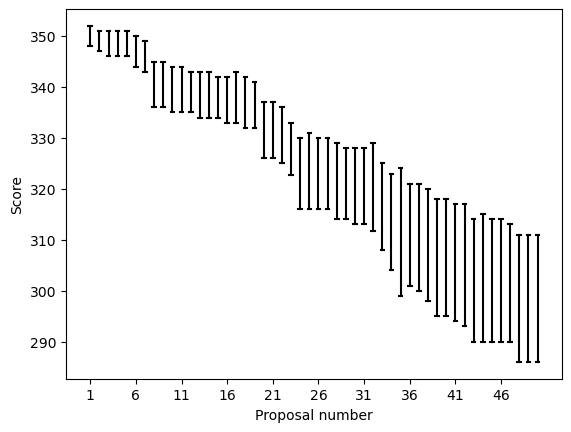

In [4]:
ax = plot_intervals(intervals[:50])

## (2) Run MERIT

We will choose $k=100$ out of $353$ intervals using MERIT. This is simple to do using the `run_merit` function. MERIT takes as input the list of intervals and the number of proposals to select ($k$). It returns the list of probabilities of selecting each proposal and the set of (randomly) selected proposals.

In [5]:
k = 100

In [6]:
selection_probabilities_merit, selected_proposals = run_merit(intervals, k)

The selection probabilities represent the probability that each proposal would get selected in the lottery. For example, as shown below proposal 1 has probability 1 of being selected (which means it is always accepted) while proposal 100 has a 0.526 chance of being selected.

In [7]:
selection_probabilities_merit[1]

1.0

In [8]:
selection_probabilities_merit[100]

0.5263157894736842

The selection probabilities sum to $k=100$, the number of selected proposals.

In [9]:
round(sum(selection_probabilities_merit), 5)

100.0

Our algorithm also outputs the indices of the proposals selected by the lottery. For example, below we show 10 of the accepted proposals with their probability of acceptance. Hence, it is possible to share both who was selected by the lottery and what probability each proposal had of being selected in the lottery.

In [10]:
list(zip(selected_proposals[:10],
     [selection_probabilities_merit[i] for i in selected_proposals[:10]]))

[(89, 0.7894736842105265),
 (91, 0.7894736842105265),
 (45, 1.0),
 (85, 1.0),
 (67, 1.0),
 (12, 1.0),
 (43, 1.0),
 (48, 1.0),
 (49, 1.0),
 (56, 1.0)]

### (2*) Run MERIT with 3 Levels of Randomziaion (Accept / Lottey / Reject)

MERIT can also be adapted to output a lottery with only 3 levels of randomization (accept, lottery or reject) where candidates in the lottery are all accepted with equal probability. To add this constraint we call `run_merit` with argument `uniform_lottery=True.`

In [12]:
selection_probabilities_merit_uniform, selected_proposals_uniform = run_merit(intervals, k, uniform_lottery=True)

Below, we confirm that this lottery has only 3 values for randomization:

In [17]:
np.unique(selection_probabilities_merit_uniform.round(4))

array([0.    , 0.4118, 1.    ])

In contrast, the unconstrained MERIT algorithm returns a lottery with 5 levels of randomization:

In [19]:
np.unique(np.array(selection_probabilities_merit).round(4))

array([0.    , 0.3053, 0.5263, 0.7895, 1.    ])

## (3) Compare to Swiss NSF selection mechanism

We can also compare the MERIT selection mechanism to selection using the Swiss NSF's approach (which sets a threshold as the k-th highest point estimate.) The [Swiss NSF algorithm](https://www.tandfonline.com/doi/full/10.1080/2330443X.2022.2086190) requires both intervals and point estimates of quality. Here, we will assume that the point estimates are just the midpoint of each interval.

In [20]:
# Point estimates are midpoint of each interval 
points = [(low + high) / 2 for low, high in intervals] 

In [21]:
# Get selection probability of each proposal using Swiss NSF method
selection_probabilities_swiss = swiss_nsf(intervals, points, k)
# Sample proposals using systematic sampling
selected_swiss = systematic_sampling(k, selection_probabilities_swiss)

Now, we compare the selection probabilities under MERIT and the Swiss NSF method. 14 proposals have a higher chance of selection under the Swiss NSF method than MERIT and 7 have a lower chance of selection.

In [22]:
diff = np.array(selection_probabilities_swiss) - np.array(selection_probabilities_merit)
len(diff[diff > 0]), len(diff[diff < 0]), (diff[diff != 0])

(14,
 7,
 array([-0.17836257, -0.17836257, -0.17836257, -0.17836257,  0.08479532,
         0.08479532,  0.08479532,  0.08479532,  0.08479532,  0.08479532,
         0.08479532,  0.08479532,  0.08479532,  0.08479532,  0.08479532,
         0.08479532,  0.30584795,  0.30584795, -0.30526316, -0.30526316,
        -0.30526316]))

In [23]:
# zip selection probabilities for comparison and make data frame
import pandas as pd
df = pd.DataFrame(list(zip(selection_probabilities_swiss, selection_probabilities_merit, selection_probabilities_merit_uniform)), columns=['Swiss NSF', 'MERIT', 'MERIT Uniform Lottery'])
df.head()

,Swiss NSF,MERIT,MERIT Uniform Lottery
0,1.0,1.0,1.0
1,1.0,1.0,1.0
2,1.0,1.0,1.0
3,1.0,1.0,1.0
4,1.0,1.0,1.0


In [24]:
df.to_csv('selection_probabilities.csv', index=True)

## (4) Compare Cutoffs under Swiss NSF and MERIT Uniform

In [68]:
# Swiss NSF cutoff is k-th highest point estimate
cutoff_swiss = len(selection_probabilities_swiss) - np.sort(points)[k]

In [65]:
cutoff_swiss

256.0

In [ ]:
# get the worst lower bound among proposals w/ p=1 and best upper bound among proposals w/ p=0 under MERIT uniform
accepted_merit_uniform = [i for i, p in enumerate(selection_probabilities_merit_uniform) if p == 1]
rejected_merit_uniform = [i for i, p in enumerate(selection_probabilities_merit_uniform) if p == 0]
worst_accepted_lower_bound = min([intervals[i][0] for i in accepted_merit_uniform])
best_rejected_upper_bound = max([intervals[i][1] for i in rejected_merit_uniform])
len(selection_probabilities_swiss) - worst_accepted_lower_bound, len(selection_probabilities_swiss) - best_rejected_upper_bound

(102.0, 103.0)

In [73]:
(selection_probabilities_merit_uniform == 1).sum(), (selection_probabilities_merit_uniform < 1).sum() - (selection_probabilities_merit_uniform == 0).sum()

(93, 17)

In [74]:
(np.array(selection_probabilities_swiss) == 1).sum(), (np.array(selection_probabilities_swiss) < 1).sum() - (np.array(selection_probabilities_swiss) == 0).sum()

(89, 18)

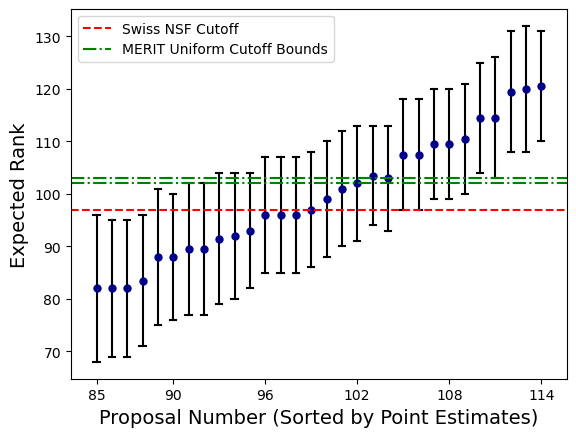

In [63]:
# Plot subset of intervals
start, end = 85, 115
intervals_flip = [(len(selection_probabilities_swiss) - high, len(selection_probabilities_swiss) - low) for low, high in intervals]
points_flip = [len(selection_probabilities_swiss) - p for p in points]
ax = plot_intervals(intervals_flip[start:end], x=points_flip[start:end])

# Set fewer x-axis labels (e.g., 6 evenly spaced ticks)
n_labels = 6
tick_positions = np.linspace(0, end - start - 1, n_labels, dtype=int)
tick_labels = np.linspace(start, end - 1, n_labels, dtype=int)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

# Rename x and y labels
ax.set_xlabel('Proposal Number (Sorted by Point Estimates)', fontsize=14)
ax.set_ylabel('Expected Rank', fontsize=14)

# Add cutoff lines
ax.axhline(y=cutoff_swiss, color='r', linestyle='--', label='Swiss NSF Cutoff')
ax.axhline(
    y=len(selection_probabilities_swiss) - worst_accepted_lower_bound,
    color='g', linestyle='-.',
    label='MERIT Uniform Cutoff Bounds'
)
ax.axhline(
    y=len(selection_probabilities_swiss) - best_rejected_upper_bound,
    color='g', linestyle='-.',
    label='_nolegend_'
)

ax.legend()